In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

features = pd.read_csv("../data/features.csv", index_col=0)

X = features.drop(columns="target_vol").values
y = features["target_vol"].values

split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape, X_test.shape)

(3171, 12) (793, 12)


In [22]:
import pandas as pd
import numpy as np

# Load original market data
df = pd.read_csv(
    "../data/market_data.csv",
    header=[0, 1],
    index_col=0
)

# Recreate daily returns
close = df["Close"]
returns = close.pct_change().dropna()

print("Returns loaded:", returns.shape)

Returns loaded: (4023, 6)


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [3]:
LOOKBACK = 30

def create_sequences(X, y, lookback):
    Xs, ys = [], []

    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])

    return np.array(Xs), np.array(ys)

train_X, train_y = create_sequences(X_train, y_train, LOOKBACK)
test_X, test_y = create_sequences(X_test, y_test, LOOKBACK)

print(train_X.shape)
print(test_X.shape)

(3141, 30, 12)
(763, 30, 12)


In [4]:
class VolatilityLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VolatilityLSTM(
    input_size=train_X.shape[2]
).to(device)

X_train_tensor = torch.tensor(train_X, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(train_y, dtype=torch.float32).unsqueeze(1).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

for epoch in range(30):
    model.train()

    optimizer.zero_grad()

    pred = model(X_train_tensor)
    loss = loss_fn(pred, y_train_tensor)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/30 | Loss: {loss.item():.6f}")

Epoch 5/30 | Loss: 0.000419
Epoch 10/30 | Loss: 0.001412
Epoch 15/30 | Loss: 0.000109
Epoch 20/30 | Loss: 0.000313
Epoch 25/30 | Loss: 0.000223
Epoch 30/30 | Loss: 0.000050


In [6]:
model.eval()

with torch.no_grad():
    X_test_tensor = torch.tensor(test_X, dtype=torch.float32).to(device)
    lstm_pred = model(X_test_tensor).cpu().numpy().flatten()

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(test_y, lstm_pred)
rmse = np.sqrt(mean_squared_error(test_y, lstm_pred))
r2 = r2_score(test_y, lstm_pred)

print(f"LSTM MAE  : {mae:.6f}")
print(f"LSTM RMSE : {rmse:.6f}")
print(f"LSTM R²   : {r2:.4f}")

LSTM MAE  : 0.003301
LSTM RMSE : 0.005563
LSTM R²   : -0.6265


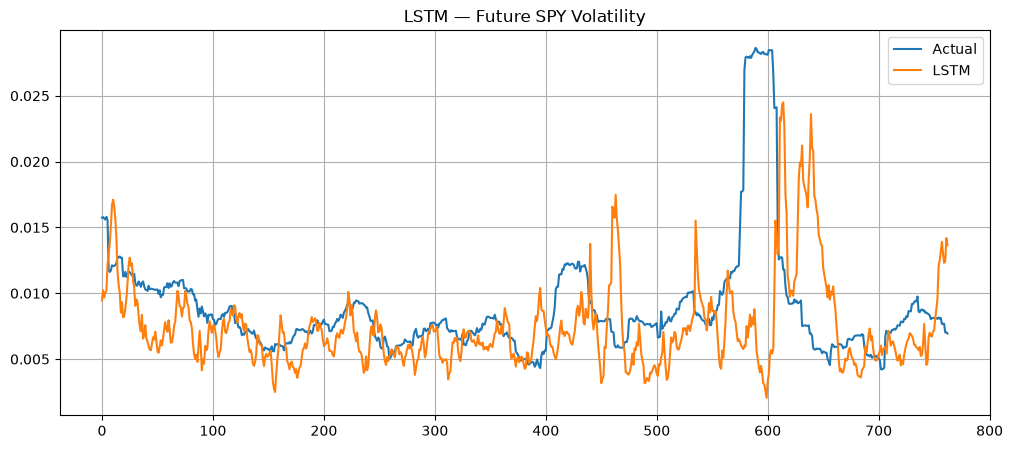

In [7]:
plt.figure(figsize=(12,5))

plt.plot(test_y, label="Actual")
plt.plot(lstm_pred, label="LSTM")

plt.title("LSTM — Future SPY Volatility")
plt.legend()
plt.grid(True)
plt.show()

MODIFYING LSTM USING BAYESIAN LSTM

In [8]:
class BayesianLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)

TRAINING

In [9]:
bayesian_model = BayesianLSTM(
    input_size=train_X.shape[2]
).to(device)

optimizer = torch.optim.Adam(
    bayesian_model.parameters(),
    lr=0.001
)

for epoch in range(30):
    bayesian_model.train()

    optimizer.zero_grad()

    pred = bayesian_model(X_train_tensor)
    loss = loss_fn(pred, y_train_tensor)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/30 | Loss: {loss.item():.6f}")

Epoch 5/30 | Loss: 0.000338
Epoch 10/30 | Loss: 0.000256
Epoch 15/30 | Loss: 0.000191
Epoch 20/30 | Loss: 0.000156
Epoch 25/30 | Loss: 0.000118
Epoch 30/30 | Loss: 0.000098


MONTE CARLO DROPOUT PREDICTION

In [10]:
def mc_dropout_predict(model, X, n_samples=100):
    model.train()  # keeps dropout active

    predictions = []

    with torch.no_grad():
        for _ in range(n_samples):
            pred = model(X).cpu().numpy().flatten()
            predictions.append(pred)

    predictions = np.array(predictions)

    mean = predictions.mean(axis=0)
    std = predictions.std(axis=0)

    return mean, std

In [11]:
X_test_tensor = torch.tensor(
    test_X,
    dtype=torch.float32
).to(device)

mc_mean, mc_std = mc_dropout_predict(
    bayesian_model,
    X_test_tensor,
    n_samples=100
)

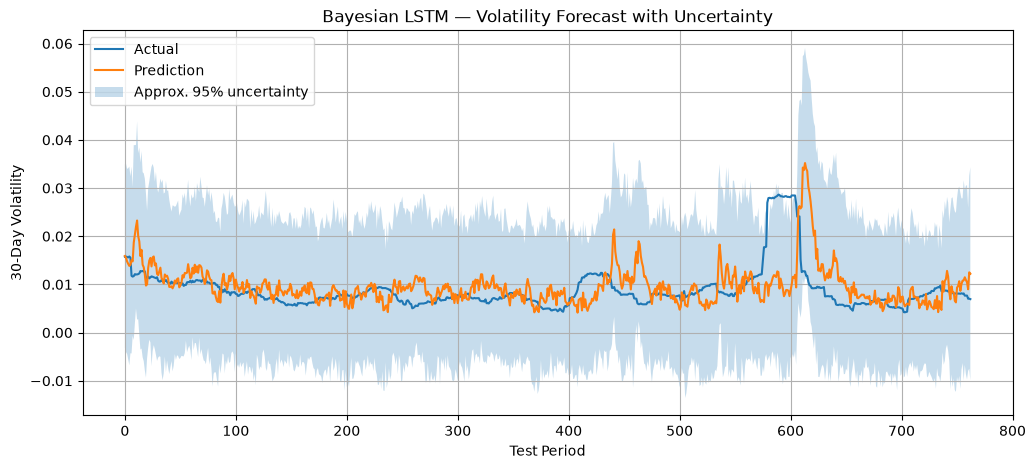

In [12]:
plt.figure(figsize=(12, 5))

x = np.arange(len(test_y))

plt.plot(x, test_y, label="Actual")
plt.plot(x, mc_mean, label="Prediction")

plt.fill_between(
    x,
    mc_mean - 2 * mc_std,
    mc_mean + 2 * mc_std,
    alpha=0.25,
    label="Approx. 95% uncertainty"
)

plt.title("Bayesian LSTM — Volatility Forecast with Uncertainty")
plt.xlabel("Test Period")
plt.ylabel("30-Day Volatility")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
coverage = np.mean(
    (test_y >= mc_mean - 2 * mc_std) &
    (test_y <= mc_mean + 2 * mc_std)
)

print(f"Interval coverage: {coverage:.2%}")
print(f"Average uncertainty: {mc_std.mean():.6f}")

Interval coverage: 97.38%
Average uncertainty: 0.008176


In [14]:
# Bayesian LSTM point forecast metrics
bayes_mae = mean_absolute_error(test_y, mc_mean)
bayes_rmse = np.sqrt(mean_squared_error(test_y, mc_mean))
bayes_r2 = r2_score(test_y, mc_mean)

comparison = pd.DataFrame({
    "Model": ["XGBoost", "LSTM", "Bayesian LSTM"],
    "MAE": [mae, 
            mean_absolute_error(test_y, lstm_pred),
            bayes_mae],
    "RMSE": [rmse,
             np.sqrt(mean_squared_error(test_y, lstm_pred)),
             bayes_rmse],
    "R2": [r2,
           r2_score(test_y, lstm_pred),
           bayes_r2]
})

comparison

,Model,MAE,RMSE,R2
0,XGBoost,0.003301,0.005563,-0.626504
1,LSTM,0.003301,0.005563,-0.626504
2,Bayesian LSTM,0.003325,0.005231,-0.437744


In [15]:
comparison.to_csv("../results/model_comparison.csv", index=False)

VOLATILITY REGIMES

In [17]:
q25 = np.quantile(y_train, 0.25)
q50 = np.quantile(y_train, 0.50)
q75 = np.quantile(y_train, 0.75)

def classify_regime(vol):
    if vol <= q25:
        return "LOW"
    elif vol <= q50:
        return "NORMAL"
    elif vol <= q75:
        return "HIGH"
    else:
        return "EXTREME"

regimes = [classify_regime(v) for v in mc_mean]

pd.Series(regimes).value_counts()

HIGH       353
NORMAL     176
EXTREME    162
LOW         72
Name: count, dtype: int64

In [18]:
exposure_map = {
    "LOW": 1.00,
    "NORMAL": 0.75,
    "HIGH": 0.40,
    "EXTREME": 0.15
}

exposure = np.array([exposure_map[r] for r in regimes])

decision_df = pd.DataFrame({
    "predicted_volatility": mc_mean,
    "uncertainty": mc_std,
    "regime": regimes,
    "recommended_exposure": exposure
})

decision_df.head()

,predicted_volatility,uncertainty,regime,recommended_exposure
0,0.015896,0.009509,EXTREME,0.15
1,0.015515,0.009777,EXTREME,0.15
2,0.014763,0.009611,EXTREME,0.15
3,0.014261,0.009927,EXTREME,0.15
4,0.013845,0.010309,EXTREME,0.15


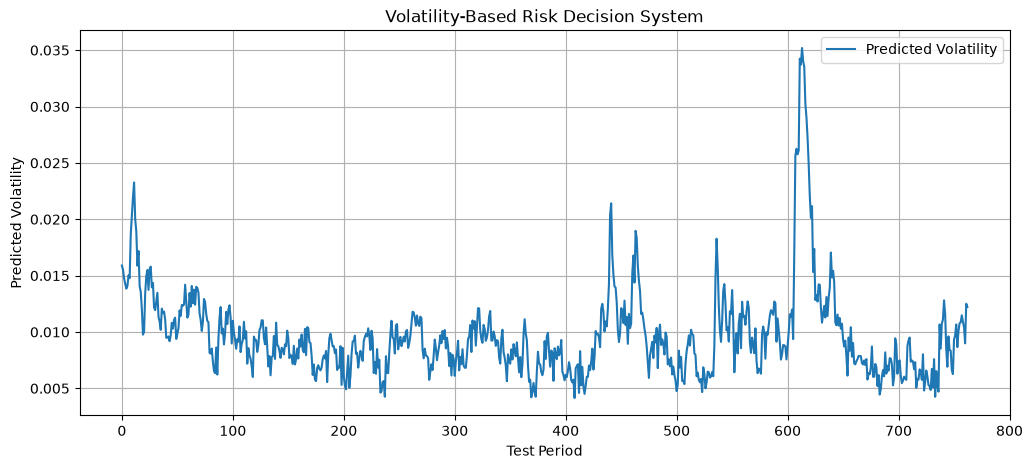

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    decision_df["predicted_volatility"],
    label="Predicted Volatility"
)

plt.title("Volatility-Based Risk Decision System")
plt.ylabel("Predicted Volatility")
plt.xlabel("Test Period")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
decision_df.to_csv(
    "../results/risk_decisions.csv",
    index=False
)

print("Risk decision system saved!")

Risk decision system saved!


In [25]:
# SPY returns corresponding to the LSTM test period
# Get the actual dates corresponding to the LSTM predictions
test_dates = features.index[split + 30:]

print("Prediction dates:", len(test_dates))
print("Predictions:", len(exposure))

Prediction dates: 763
Predictions: 763


In [26]:
# Load SPY returns with dates
spy_returns = returns["SPY"]

# Select exactly the prediction dates
spy_test_returns = spy_returns.loc[
    spy_returns.index.intersection(test_dates)
].values

print("SPY returns:", len(spy_test_returns))
print("Exposure:", len(exposure))

SPY returns: 763
Exposure: 763


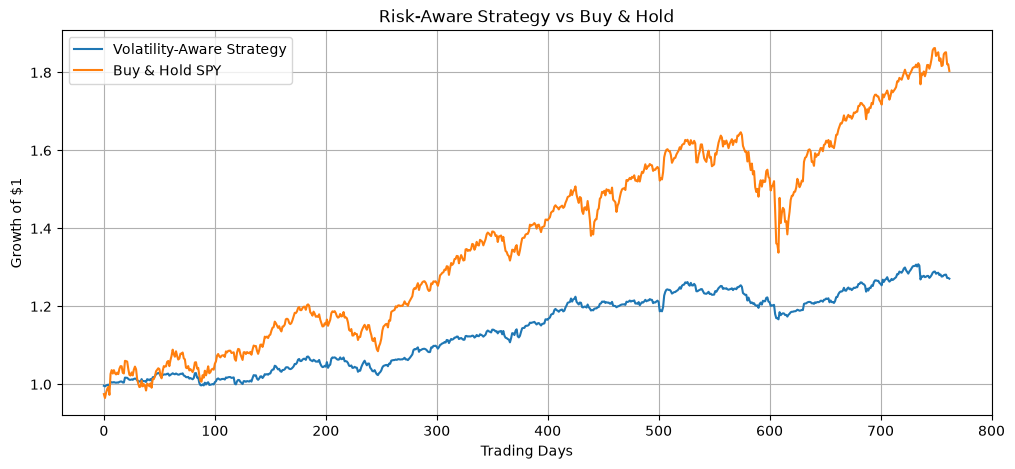

In [27]:
strategy_returns = spy_test_returns * exposure
benchmark_returns = spy_test_returns

strategy_wealth = (1 + strategy_returns).cumprod()
benchmark_wealth = (1 + benchmark_returns).cumprod()

plt.figure(figsize=(12, 5))

plt.plot(strategy_wealth, label="Volatility-Aware Strategy")
plt.plot(benchmark_wealth, label="Buy & Hold SPY")

plt.title("Risk-Aware Strategy vs Buy & Hold")
plt.xlabel("Trading Days")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
def performance_metrics(r):
    annual_return = (1 + r).prod() ** (252 / len(r)) - 1
    annual_vol = r.std() * np.sqrt(252)
    sharpe = annual_return / annual_vol if annual_vol != 0 else 0

    cumulative = (1 + r).cumprod()
    drawdown = cumulative / np.maximum.accumulate(cumulative) - 1
    max_drawdown = drawdown.min()

    return annual_return, annual_vol, sharpe, max_drawdown


strategy_metrics = performance_metrics(strategy_returns)
benchmark_metrics = performance_metrics(benchmark_returns)

comparison = pd.DataFrame({
    "Metric": [
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Max Drawdown"
    ],
    "Risk-Aware Strategy": strategy_metrics,
    "Buy & Hold": benchmark_metrics
})

comparison

,Metric,Risk-Aware Strategy,Buy & Hold
0,Annual Return,0.082428,0.215117
1,Annual Volatility,0.068378,0.160331
2,Sharpe Ratio,1.205475,1.341711
3,Max Drawdown,-0.075813,-0.187552


In [29]:
comparison.to_csv(
    "../results/backtest_comparison.csv",
    index=False
)

decision_df.to_csv(
    "../results/risk_decisions.csv",
    index=False
)

print("All results saved.")

All results saved.


Market Data
     ↓
EDA
     ↓
PCA
     ↓
Feature Engineering
     ↓
XGBoost ───────┐
               ├──→ Volatility Forecast
LSTM ──────────┤
               ↓
Bayesian LSTM + MC Dropout
               ↓
Prediction + Uncertainty
               ↓
Risk Regime
               ↓
Exposure Decision
               ↓
Backtest vs Buy & Hold